In [221]:
import numpy as np
import scipy.constants as cte 
import matplotlib.pyplot as plt
plt.rcParams['mathtext.fontset'] = 'cm'
import matplotlib.animation as animation
from matplotlib import rc
from itertools import chain
from tqdm import tqdm, trange

In [22]:
def get_matrices(
    dx: float, # passo no espaço, 'h'
    dt: float, # passo no tempo, 'delta'
    num_points: int, # numero de pontos do 'espaço'
    potential: np.array, # potencial em função de x, V(x)
    mass: float=1.0, # massa do quanton, se quiser e.g. massa do eletron usa 'cte.m_e'
    hbar: float=1.0, # cte. de plank reduzida, se quiser valor do SI usa 'cte.hbar'
) -> tuple[np.array, np.array]:
    '''
    retorna as matrizes A e B do método de Crank-Nicolson.
    '''
    alpha = 1j*hbar*dt/(4*mass*dx**2)
    beta_values = [1j*dt*v/(2*hbar) for v in potential]
    xi_values = [1 + 2*alpha + beta for beta in beta_values]
    gamma_values = [1 - 2*alpha - beta for beta in beta_values]

    matrix_A = np.zeros((num_points, num_points), dtype=np.complex128)

    for j in range(num_points):
        matrix_A[j, j] = xi_values[j]

    for j in range(num_points - 1):
        matrix_A[j, j+1] = -alpha
        matrix_A[j+1, j] = -alpha

    matrix_B = np.zeros((num_points, num_points), dtype=np.complex128)

    for j in range(num_points):
        matrix_B[j, j] = gamma_values[j]

    for j in range(num_points - 1):
        matrix_B[j, j+1] = alpha
        matrix_B[j+1, j] = alpha

    return matrix_A, matrix_B

# exemplo V(x)=0, 5 pontos
get_matrices(dx=1e-2, dt=1e-4, num_points=5, potential=np.zeros(5))

(array([[ 1.+0.5j , -0.-0.25j,  0.+0.j  ,  0.+0.j  ,  0.+0.j  ],
        [-0.-0.25j,  1.+0.5j , -0.-0.25j,  0.+0.j  ,  0.+0.j  ],
        [ 0.+0.j  , -0.-0.25j,  1.+0.5j , -0.-0.25j,  0.+0.j  ],
        [ 0.+0.j  ,  0.+0.j  , -0.-0.25j,  1.+0.5j , -0.-0.25j],
        [ 0.+0.j  ,  0.+0.j  ,  0.+0.j  , -0.-0.25j,  1.+0.5j ]]),
 array([[1.-0.5j , 0.+0.25j, 0.+0.j  , 0.+0.j  , 0.+0.j  ],
        [0.+0.25j, 1.-0.5j , 0.+0.25j, 0.+0.j  , 0.+0.j  ],
        [0.+0.j  , 0.+0.25j, 1.-0.5j , 0.+0.25j, 0.+0.j  ],
        [0.+0.j  , 0.+0.j  , 0.+0.25j, 1.-0.5j , 0.+0.25j],
        [0.+0.j  , 0.+0.j  , 0.+0.j  , 0.+0.25j, 1.-0.5j ]]))

In [23]:
def thomas_algorithm(A: np.array, y: np.array) -> np.array:
    n = A.shape[0]
    B = np.zeros((n, n + 1), dtype=np.complex128)
    T = B
    B[:,0:n] = A
    B[:,n] = y

    for k in range(0, n-1):
        if B[k,k] == 0:
            for l in range(k+1, k+2):
                if B[l,k] != 0:
                    T[n-1,:] = B[k,:]
                    B[k,:] = B[l,:]
                    B[l,:] = T[n-1,:]
                    break
        if B[k,k] == 0:
            print(f'Todos os coeficientes de x_{k} são nulos')
            return None
        T[k,:] = B[k,:]
        for j in range(k+1, k+2):
            T[j,:] = B[j,:] - (B[j,k]/B[k,k])*B[k,:]
        B = T

    x = np.zeros(n, dtype=np.complex128)
    x[n-1] = B[n-1,n]/B[n-1,n-1]
    for j in range(n-2, -1, -1):
        soma = 0
        for l in range(n-1, j, -1):
            soma += B[j,l]*x[l]
        x[j] = (B[j,n]-soma)/B[j,j]
    return x

In [28]:
def get_initial_condition(
    k: float, 
    d: float,
    num_points: int,
    start: float,
    end: float
) -> tuple[np.array, np.array]:

    x_values = np.linspace(start, end, num_points)
    
    # pacote de onda gaussiano
    psi_0 = 1/(np.pi**(1/4) * d**(1/2)) * np.exp(1j*k*x_values - x_values**2/(2*d**2))

    return psi_0, x_values

In [222]:
def get_psi_evolution(
    num_steps: int, 
    dt: float, 
    psi_0: np.array, 
    matrix_A: np.array, 
    matrix_B: np.array
) -> np.array:

    t_values = np.arange(0, num_steps*dt, dt)

    b_vectors = [[] for j, _ in enumerate(t_values)]
    psi_t = [[] for j, _ in enumerate(t_values)]
    psi_t[0] = psi_0

    for j in trange(0, len(psi_t)-1):

        b_vectors[j] = np.matmul(matrix_B, psi_t[j])

        psi_t[j+1] = thomas_algorithm(matrix_A, b_vectors[j])

    return psi_t

In [232]:
def plot_animation(psi_t, potential):

    rc('animation', html='jshtml')
    nsteps = len(psi_t)
    step_size = max(1, nsteps // 120)
    frames = range(0, nsteps, step_size)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.grid(ls='--', alpha=0.5)
    line_re, = ax.plot([], [], '-',  color='k', lw=1.1, label=r'${\rm Re}(\psi)$')
    line_im, = ax.plot([], [], '--', color='g', lw=1.1, label=r'${\rm Im}(\psi)$')
    line_ab, = ax.plot([], [], '-.', color='b', lw=1.1, label=r'$|\psi|^2$')

    ax.plot(x_values, potential, '.--', color='r', label=r'$V(x)$')
    
    ax.set_xlim(x_values.min()-1.0, x_values.max()+1.0)
    ax.set_ylim(-0.5, 0.7)
    plt.xlabel(r'$x$', fontsize=20)
    plt.legend(fontsize=18)
    plt.tight_layout()

    def init():
        line_re.set_data([], [])
        line_im.set_data([], [])
        line_ab.set_data([], [])
        return line_re, line_im, line_ab

    def update(step):
        psi = psi_t[step]
        line_re.set_data(x_values, np.real(psi))
        line_im.set_data(x_values, np.imag(psi))
        line_ab.set_data(x_values, np.abs(psi)**2)
        return line_re, line_im, line_ab

    anim = animation.FuncAnimation(
        fig, update, frames=frames,
        init_func=init, interval=60, blit=True
    )
    plt.close(fig)
    return anim

In [159]:
num_points = 500        # numero de pontos do espaço
num_steps=1e3           # numero de passos no tempo
start, end = -5.0, 50.0 # contornos x_0 e x_{N-1}
k, d = 1.5, np.sqrt(2)  # parametros da gaussiana
dx, dt = 1e-2, 1e-4     # deltas para as derivadas
potential = np.zeros(num_points) # particula livre

psi_0, x_values = get_initial_condition(k, d, num_points, start, end)
matrix_A, matrix_B = get_matrices(dx, dt, num_points, potential)

matrix_A, matrix_B
psi_t = get_psi_evolution(num_steps, dt, psi_0, matrix_A, matrix_B)
plot_animation(psi_t, potential)

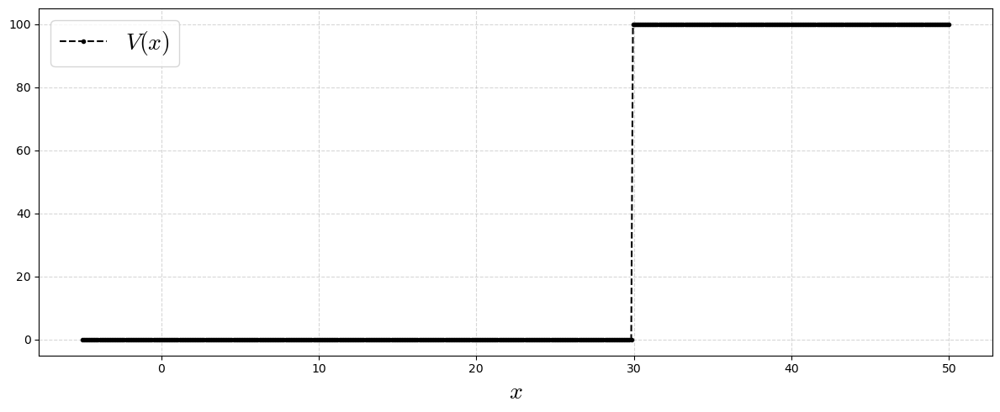

In [ ]:
def get_potential(potential_list, num_points):

    start, end = potential_list[0][1], potential_list[-1][2]
    
    pos_list = [potential_list[j][1] for j in range(1, len(potential_list))]

    position_to_point = lambda position: (
        int((position - start) / abs(end - start) * (num_points - 1))
    )
    points = [position_to_point(pos) for pos in pos_list]

    potential_values = [potential_list[j][0] for j, _ in enumerate(potential_list)]

    ranges = (
        [range(0, points[0])] 
        + [range(points[j], points[j+1]) for j in range(0, len(points)-1)] 
        + [range(points[-1], num_points)]
    )

    potential_array = [[v for _ in r] for v, r in zip(potential_values, ranges)]

    potential_array = np.array(
        [x for x in chain.from_iterable(potential_array)], dtype=float
    )

    return potential_array    
    
# test = [ 
#     [0, -5, 30], 
#     [100, 30, 50]
# ] 
# num_points = 500
# x_values = np.linspace(-5, 50, num_points)
# potential = get_potential(test, num_points)

# fig = plt.figure(figsize=(12, 5))
# plt.grid(ls='--', alpha=0.5)
# plt.plot(x_values, potential, '.--', color='k', label=r'$V(x)$')
# plt.xlabel(r'$x$', fontsize=20)
# plt.legend(fontsize=20)
# plt.tight_layout()
# plt.show()

In [230]:
num_points = 500         # numero de pontos do espaço
num_steps=5e3            # numero de passos no tempo
start, end = -30.0, 30.0 # contornos x_0 e x_{N-1}
k, d = 1, np.sqrt(2)     # parametros da gaussiana
dx, dt = 1e-2, 1e-4      # deltas para as derivadas
potential = get_potential([[1e4, -30, -20], [0, -20, 20], [1e4, 20, 30]], num_points)

psi_0, x_values = get_initial_condition(k, d, num_points, start, end)
matrix_A, matrix_B = get_matrices(dx, dt, num_points, potential)
psi_t = get_psi_evolution(num_steps, dt, psi_0, matrix_A, matrix_B)

100%|██████████| 4999/4999 [01:17<00:00, 64.80it/s]


In [233]:
plot_animation(psi_t, potential) 